# Dynamic Dijkstra's Path Planning Algorithm

## What this file is doing
This notebook demonstrates Dijkstra's algorithm for path planning on a 2D grid. It doesn't just calculate the final path; it dynamically visualizes the algorithm's exploration process step-by-step so you can see exactly how it searches the environment to find the shortest route from a start point to a goal point while avoiding obstacles.

## The Algorithm
Dijkstra's algorithm is a greedy search algorithm used to find the shortest path between nodes in a graph (in our case, a grid). 
1. It maintains a **Priority Queue** of nodes to explore, sorted by the total cost to reach them from the start.
2. It starts at the origin, calculates the cost to all directly connected neighbors, and adds them to the queue.
3. It always picks the unvisited node with the lowest known cost, making it guaranteed to find the shortest path (if one exists).
4. It keeps track of the "parent" of each node so the final path can be traced back from the goal.

## Implementation Details
* **Environment:** A 2D Numpy array where `0` represents free space and `1` represents an obstacle.
* **Queue:** Python's built-in `heapq` library is used to efficiently fetch the lowest-cost node.
* **Visualization:** `matplotlib.pyplot` combined with `IPython.display.clear_output` allows us to clear and redraw the plot in real-time, creating an animation directly inside the notebook.

In [3]:
import numpy as np             # Used for creating and manipulating the 2D grid (matrix)
import matplotlib.pyplot as plt # Used for plotting the grid and path visually
import heapq                   # Used to create a priority queue (min-heap) for Dijkstra
from IPython import display    # Used to clear the output of the cell dynamically for animation
import time                    # Used to add a small delay to make the animation visible

### Step 2: Define the Environment
Here we set up our 2D grid map. We define the start coordinates, the goal coordinates, and place some obstacles in the way to test the algorithm's pathfinding capabilities.

In [4]:
grid_size=10 # 10x10 map

#create any empty map
grid=np.zeros((grid_size,grid_size))

# add obstacles
grid[2:8, 4] = 1 # Creates a vertical wall from row 2 to 7 in column 4
grid[2, 4:7] = 1 # Creates a horizontal wall from col 4 to 6 in row 2
grid[7, 2:5] = 1 # Creates a horizontal wall from col 2 to 4 in row 7

# Define start and goal nodes. Format: Tuple of (row, column)
start = (0, 0) # The starting position at top-left. Dimension: 1x2 tuple
goal = (9, 9)  # The target position at bottom-right. Dimension: 1x2 tuple

### Step 3: Dijkstra's Algorithm with Dynamic Visualization
This block contains the core logic. It explores the grid, calculates costs, and plots the current state of the search at every iteration. 
* Yellow cells are being explored.
* The algorithm checks up, down, left, and right (no diagonals in this setup).

In [5]:
def run_dijkstra(grid,start,goal):
    rows,cols=grid.shape

    #priority queue to store point, sort by smallest distance from the start to the largest
    #  List of tuples -> [(cost, (row, col))]. Example: [(0, (0, 0))]
    pq=[]

    #push the start node to the pq iwth a cost of 0
    heapq.heappush(pq,(0,start))

    #dictionary to store the cost to reach each node
    costs={start:0}

    #dict to store the parent of each node
    #Key: child_tuple, Value: parent_tuple.
    came_from={start:None}

    #visited set to keep track of the nodes we have already fully explored
    # Format: set of tuples. Example: {(0,0), (0,1)}
    visited=set()

    #directions
    directions=[(0,1),(0,-1),(1,0),(-1,0)]

    fig, ax = plt.subplots(figsize=(6, 6))
    

    #run as long as pq not empty
    while pq:
        #pop the node with the lowest cost
        #current_cost = int, current = tuple (row, col)
        current_cost,current=heapq.heappop(pq)

        #if we reached the goal, break the loop
        if current==goal:
            break
        #add the current node to the visited set
        visited.add(current)

        #visualization
        ax.clear()
        ax.imshow(grid,cmap='Greys',origin='upper')

        #plot all visted nodes 
        for v in visited:
            #v[1] is x (col), v[0] is y (row)
            ax.scatter(v[1],v[0],c='lightblue',marker='s',s=100)

        # Plot the start node as a green square
        ax.scatter(start[1], start[0], c='green', marker='s', s=100, label='Start') 
        # Plot the goal node as a red square
        ax.scatter(goal[1], goal[0], c='red', marker='s', s=100, label='Goal') 
        # Plot the node currently being evaluated as yellow
        ax.scatter(current[1], current[0], c='yellow', marker='s', s=100)

        ax.grid(True) # Show gridlines
        ax.set_xticks(np.arange(-0.5, cols, 1)) # Set gridlines exactly between cells (X axis)
        ax.set_yticks(np.arange(-0.5, rows, 1)) # Set gridlines exactly between cells (Y axis)
        ax.set_xticklabels([]) # Hide axis numbers for a cleaner look
        ax.set_yticklabels([]) # Hide axis numbers for a cleaner look
        
        display.display(fig)  # Push the figure to the Jupyter output
        display.clear_output(wait=True) # Clear the output immediately for the next frame
        time.sleep(0.05) # Pause for 50 milliseconds so the human eye can see the animation
        # --- END VISUALIZATION BLOCK ---

        #check 4 neighbors:
        for dr,dc in directions:
            neighbor=(current[0]+dr,current[1]+dc)

            if 0<=neighbor[0]<rows and 0<=neighbor[1]<cols:
                #check if the neightbor is an obstacle if so skip
                if grid[neighbor[0],neighbor[1]]==1:
                    continue

                if neighbor in visited:
                    continue

                new_cost=costs[current]+1

                #if we havent see this neighbor we found a cheaper way to reach it:
                if neighbor not in costs or new_cost<costs[neighbor]:
                    costs[neighbor]=new_cost
                    #push it into pq
                    heapq.heappush(pq,(new_cost,neighbor))
                    #came from
                    came_from[neighbor]=current
    plt.close()
    return came_from,costs
        


### Step 4: Run it and Extract the Path
Now we call our function. Once it finishes animating the search, we use the `came_from` dictionary to trace backwards from the `goal` to the `start`. Finally, we plot the completed, optimal route.

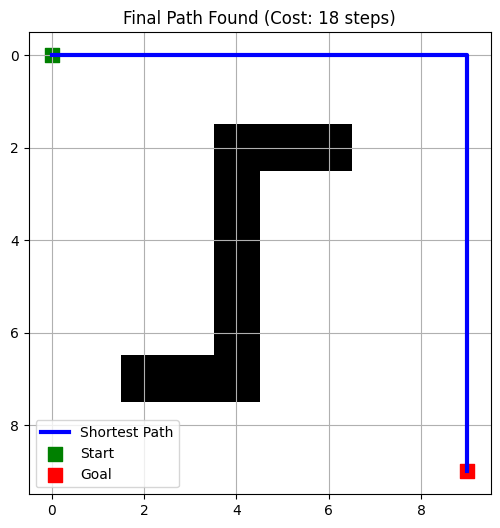

In [6]:
# 1. Run the animated algorithm. It returns the dictionary needed to trace the path.
came_from, final_costs = run_dijkstra(grid, start, goal) 

# 2. Reconstruct the path. We start at the goal and work backwards.
# Initialize an empty list to store the path coordinates. Format: list of tuples
path = [] 
current_node = goal # Start tracing backwards from the goal tuple (9, 9)

# Loop backwards until we hit a node that doesn't have a parent (which is the start node)
while current_node != start:
    path.append(current_node) # Add the current node to our path list
    # Look up the parent of the current node in our dictionary.
    # Example: if current is (9,9), came_from[(9,9)] might be (8,9)
    current_node = came_from.get(current_node) 
    
    # Safety check: if there is no parent and we aren't at the start, there is no valid path!
    if current_node is None: 
        print("No valid path found!")
        path = [] # Empty the path list since it's invalid
        break 

# If a path was found, we need to add the start node and reverse the list (Start -> Goal)
if path:
    path.append(start) # Append the start tuple (0, 0)
    path.reverse() # Reverse the list in-place so it goes from Start to Goal

    # 3. Plot the final result
    plt.figure(figsize=(6, 6)) # Create a new static plot
    plt.imshow(grid, cmap='Greys', origin='upper') # Draw the map
    
    # Extract just the X (columns) and Y (rows) values from our path list of tuples
    # path is [(0,0), (0,1)...]. path_y extracts all first elements [0, 0...], path_x extracts seconds [0, 1...]
    path_y = [p[0] for p in path] 
    path_x = [p[1] for p in path] 
    
    # Plot the path as a blue line connecting the coordinates
    plt.plot(path_x, path_y, color='blue', linewidth=3, label='Shortest Path') 
    
    # Mark start and goal
    plt.scatter(start[1], start[0], c='green', marker='s', s=100, label='Start') 
    plt.scatter(goal[1], goal[0], c='red', marker='s', s=100, label='Goal') 
    
    plt.grid(True)
    plt.legend() # Show the legend
    plt.title(f"Final Path Found (Cost: {final_costs.get(goal, 'N/A')} steps)") # Display total cost
    plt.show() # Render the final static plot